# Modelling loan payback

### Step 1 - set up

In [2]:
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ml methods
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# normally you'd import train_test_split, but data has already been divided
#from sklearn.model_selection import train_test_split

# data import - note data was saved locally via kaggle API download
data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

### Step 2 - Getting to know the data: exploratory data analysis

In [3]:
# data exploration (train data)
data_train.columns.to_list()
# remove id col
data_train.drop('id', inplace=True, axis=1)
data_train.describe()
# further processing needed to handle categorical variables

# payback outcome breakdown
pd.DataFrame({
    'n': data_train['loan_paid_back'].value_counts().map('{:,}'.format),
    'percentage': 100*data_train['loan_paid_back'].value_counts(normalize=True).round(3)
    })

,n,percentage
loan_paid_back,,
1.0,"474,494",79.9
0.0,"119,500",20.1


In [4]:
# feature comparison by payback group 
filter = data_train['loan_paid_back'] == 1
data_train_payers = data_train[filter]
# drop outcome label
filter = data_train['loan_paid_back'] == 0
data_train_non_payers = data_train[filter]

# TODO: SEARCH if there's a package that already does below

# save description objects (only numeric vars)
payers_desc = data_train_payers.describe().drop('loan_paid_back', axis=1)
non_payers_desc = data_train_non_payers.describe().drop('loan_paid_back', axis=1)

#### Box plots

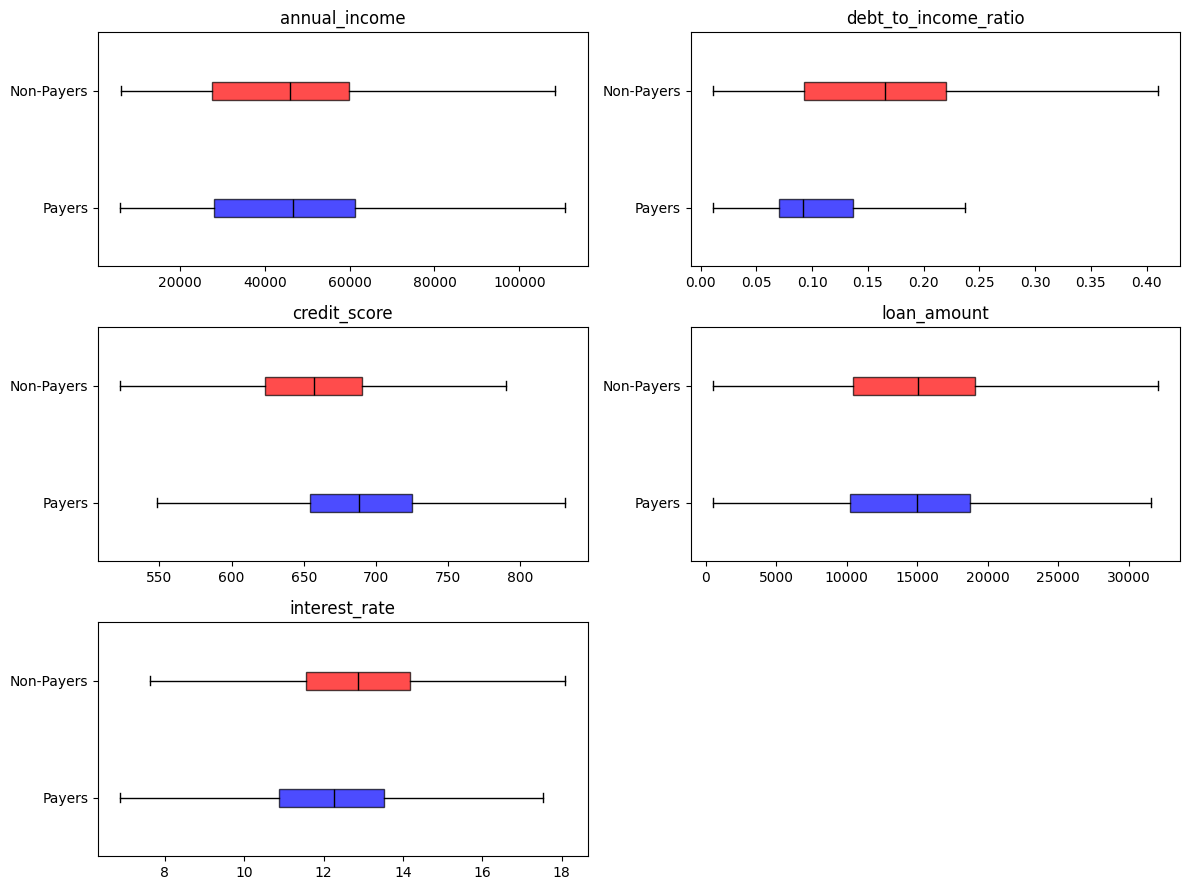

In [22]:
# determine grid size
numeric_cols = data_train_payers.select_dtypes(include=np.number).columns.drop('loan_paid_back')
num_cols = len(numeric_cols)
ncols = 2
nrows = int(np.ceil(num_cols/2)) # in case of single row/col

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 9))
axes = axes.flatten()

# make boxplots
for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # create boxplot for col
    bp = ax.boxplot(
        [data_train_payers[col], data_train_non_payers[col]],
        labels=['Payers', 'Non-Payers'],
        patch_artist=True,
        # horizontal orientation of bars
        vert=False,
        # don't show outliers, to improve visibility?
        showfliers=False
        )
    
    colors = ['blue', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set(color='black')
    ax.set_title(col)

#hide unused subplots
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

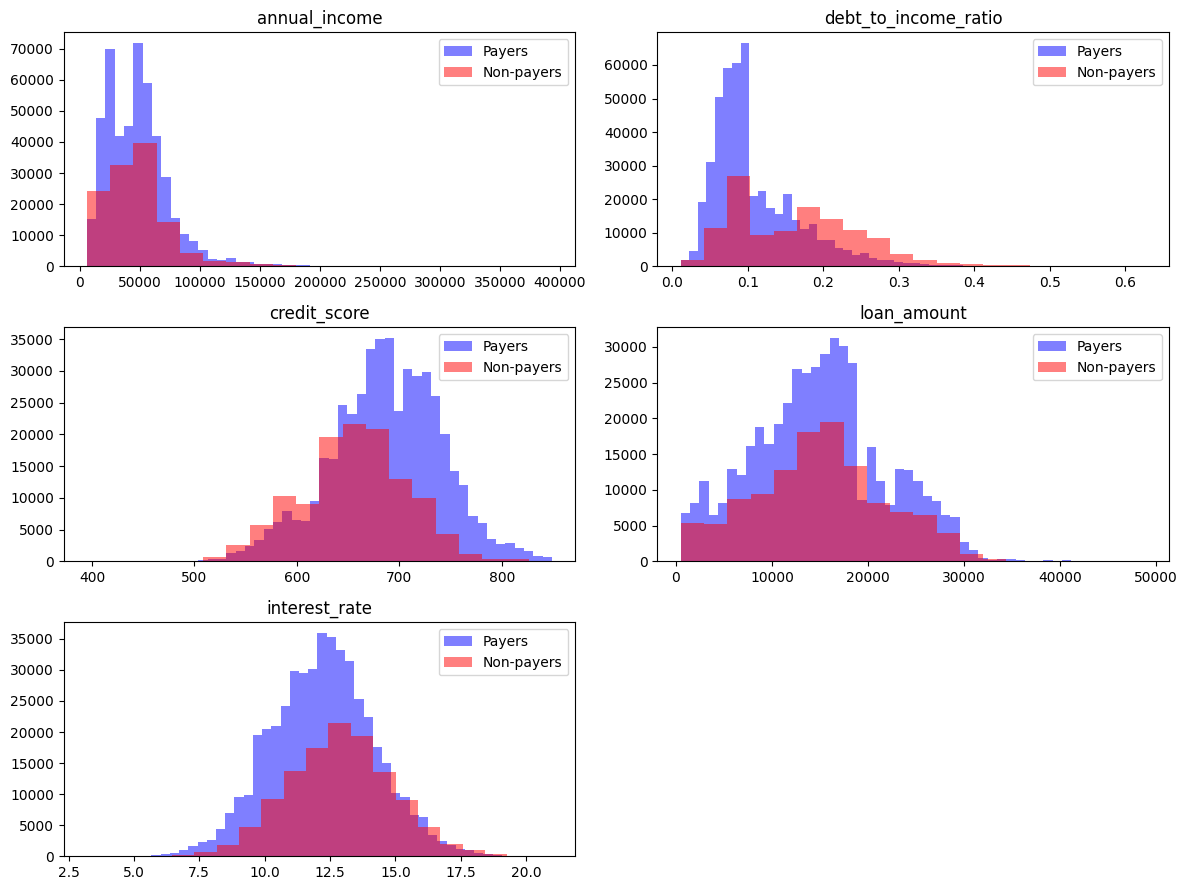

In [21]:
# try histograms
numeric_cols = data_train_payers.select_dtypes(include=np.number).columns.drop('loan_paid_back')
num_cols = len(numeric_cols)
nrows = int(np.ceil(num_cols/2))
ncols = 2

fig, axes = plt.subplots(nrows,ncols, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # create histograms for each group
    ax.hist(
        data_train_payers[col], bins=50, alpha=0.5, color='blue',
        label='Payers'#, density=True
        )
        
    ax.hist(
        data_train_non_payers[col], bins=20, alpha=0.5, color='red',
        label='Non-payers' #, density=True
        )
    
    ax.set_title(col)
    ax.legend()

#hide unused subplots
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()